## **1. Dataset Loading**

**Purpose:**

Load the HR Attrition dataset from Google Drive for further preprocessing and analysis.

In [14]:
from google.colab import drive
drive.mount('/content/drive')
datasetpath = '/content/drive/My Drive/HR_Attrition_dataset.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pandas as pd
df = pd.read_csv(datasetpath)
df

,Employee_ID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,MonthlyIncome,...,JobSatisfaction,MaritalStatus,NumCompaniesWorked,OverTime,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,1,56,Yes,Travel Rarely,Network Administration,24,Graduation,5,Male,186630,...,4,Married,7,Yes,85,9,1,7,2,4
1,2,46,Yes,Travel Rarely,Software Development,45,Degree,5,Male,78553,...,2,Divorced,3,No,22,18,4,1,2,0
2,3,32,No,No Travel,Data Science,30,Master's,3,Female,175003,...,2,Single,2,Yes,100,0,4,5,5,8
3,4,60,Yes,Travel Frequently,Data Science,42,Graduation,2,Female,100795,...,3,Married,5,No,72,17,2,1,7,3
4,5,25,No,No Travel,Network Administration,26,Graduation,4,Female,75256,...,4,Single,9,No,21,12,5,7,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,33,Yes,Travel Frequently,Data Science,35,Degree,4,Male,108566,...,2,Single,5,No,68,2,2,1,4,4
9996,9997,62,No,Travel Rarely,Data Science,30,Degree,5,Female,115593,...,5,Married,3,Yes,55,4,1,0,1,2
9997,9998,32,No,Travel Rarely,Data Science,44,Degree,4,Female,160923,...,4,Divorced,1,No,87,12,5,8,0,1
9998,9999,18,Yes,Travel Rarely,Data Science,46,Graduation,2,Male,163365,...,4,Married,9,Yes,79,10,3,8,8,3


## **2. Initial Data Exploration (EDA)**

**2.1 View First Records**

In [17]:
df.head()

,Employee_ID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,MonthlyIncome,...,JobSatisfaction,MaritalStatus,NumCompaniesWorked,OverTime,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,1,56,Yes,Travel Rarely,Network Administration,24,Graduation,5,Male,186630,...,4,Married,7,Yes,85,9,1,7,2,4
1,2,46,Yes,Travel Rarely,Software Development,45,Degree,5,Male,78553,...,2,Divorced,3,No,22,18,4,1,2,0
2,3,32,No,No Travel,Data Science,30,Master's,3,Female,175003,...,2,Single,2,Yes,100,0,4,5,5,8
3,4,60,Yes,Travel Frequently,Data Science,42,Graduation,2,Female,100795,...,3,Married,5,No,72,17,2,1,7,3
4,5,25,No,No Travel,Network Administration,26,Graduation,4,Female,75256,...,4,Single,9,No,21,12,5,7,2,4


## **2.2 Dataset Size**

In [18]:
df.shape

(10000, 23)

## **2.3 Dataset Information**

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Employee_ID              10000 non-null  int64 
 1   Age                      10000 non-null  int64 
 2   Attrition                10000 non-null  object
 3   BusinessTravel           10000 non-null  object
 4   Department               10000 non-null  object
 5   DistanceFromHome         10000 non-null  int64 
 6   Education                10000 non-null  object
 7   EnvironmentSatisfaction  10000 non-null  int64 
 8   Gender                   10000 non-null  object
 9   MonthlyIncome            10000 non-null  int64 
 10  JobInvolvement           10000 non-null  int64 
 11  JobLevel                 10000 non-null  int64 
 12  JobRole                  10000 non-null  object
 13  JobSatisfaction          10000 non-null  int64 
 14  MaritalStatus            10000 non-null

## **2.4 Statistical Summary**

In [20]:
df.describe()

,Employee_ID,Age,DistanceFromHome,EnvironmentSatisfaction,MonthlyIncome,JobInvolvement,JobLevel,JobSatisfaction,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,40.494900,25.445100,2.987800,114492.519000,2.986300,4.53120,2.991900,5.009800,50.148600,9.978800,3.003600,4.978000,5.003500,3.985400
std,2886.89568,13.162298,14.390431,1.414939,49009.843725,1.422995,2.28564,1.427178,3.166371,29.154528,6.110686,1.412865,3.177849,3.148187,2.587944
min,1.00000,18.000000,1.000000,1.000000,30078.000000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2500.75000,29.000000,13.000000,2.000000,72124.000000,2.000000,3.00000,2.000000,2.000000,25.000000,5.000000,2.000000,2.000000,2.000000,2.000000
50%,5000.50000,40.000000,25.000000,3.000000,114499.000000,3.000000,5.00000,3.000000,5.000000,51.000000,10.000000,3.000000,5.000000,5.000000,4.000000
75%,7500.25000,52.000000,38.000000,4.000000,157213.000000,4.000000,7.00000,4.000000,8.000000,75.000000,15.000000,4.000000,8.000000,8.000000,6.000000
max,10000.00000,63.000000,50.000000,5.000000,199989.000000,5.000000,8.00000,5.000000,10.000000,100.000000,20.000000,5.000000,10.000000,10.000000,8.000000


## **3. Data Quality Checks**

**3.1 Missing Values**

In [21]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EnvironmentSatisfaction,0
Gender,0
MonthlyIncome,0


## **3.2 Duplicate Records**

In [22]:
df.duplicated().sum()

np.int64(0)

## **3.3 Dataset Size After Cleaning**

In [23]:
df.shape

(10000, 23)

## **4. Attrition Distribution Analysis**

**4.1 Attrition Count**

In [24]:
df['Attrition'].value_counts()

,count
Attrition,
No,7753
Yes,2247


##**4.2 Attrition Percentage**

In [25]:
df['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,77.53
Yes,22.47


## **5. Feature Engineering**

* Creating new features to improve model performance.


**5.1 Experience Ratio**

In [26]:
df['ExperienceRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df["ExperienceRatio"] = df["ExperienceRatio"].fillna(0)

##**5.2 Promotion Gap**

In [27]:
df["PromotionGap"] = df["YearsAtCompany"] - df["YearsSinceLastPromotion"]

##**5.3 Income per Job Level**

In [28]:
df["IncomePerLevel"] = df["MonthlyIncome"] / df["JobLevel"]

##**5.4 Company Switch Rate**

In [29]:
df["CompanySwitchRate"] = df["NumCompaniesWorked"] / df["TotalWorkingYears"]
df["CompanySwitchRate"] = df["CompanySwitchRate"].fillna(0)

##**5.5 Role Stability**

In [30]:
df["RoleStability"] = df["YearsInCurrentRole"] / df["YearsAtCompany"]
df["RoleStability"] = df["RoleStability"].fillna(0)

##**5.6 Promotion Delay**

In [31]:
df["PromotionDelay"] = df["TotalWorkingYears"] - df["YearsSinceLastPromotion"]

##**5.7 Low Income Flag**

In [32]:
df["LowIncomeFlag"] = df["MonthlyIncome"].apply(lambda x: 1 if x < 30000 else 0)

##**6. Target Variable Encoding**

* Convert Attrition to numeric format.

In [33]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

In [34]:
df['Attrition']

,Attrition
0,1
1,1
2,0
3,1
4,0
...,...
9995,1
9996,0
9997,0
9998,1


In [35]:
df.head()

,Employee_ID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,MonthlyIncome,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,ExperienceRatio,PromotionGap,IncomePerLevel,CompanySwitchRate,RoleStability,PromotionDelay,LowIncomeFlag
0,1,56,1,Travel Rarely,Network Administration,24,Graduation,5,Male,186630,...,7,2,4,0.700000,3,31105.000,0.777778,0.285714,5,0
1,2,46,1,Travel Rarely,Software Development,45,Degree,5,Male,78553,...,1,2,0,0.052632,1,15710.600,0.166667,2.000000,18,0
2,3,32,0,No Travel,Data Science,30,Master's,3,Female,175003,...,5,5,8,5.000000,-3,43750.750,inf,1.000000,-8,0
3,4,60,1,Travel Frequently,Data Science,42,Graduation,2,Female,100795,...,1,7,3,0.055556,-2,12599.375,0.294118,7.000000,14,0
4,5,25,0,No Travel,Network Administration,26,Graduation,4,Female,75256,...,7,2,4,0.538462,3,37628.000,0.750000,0.285714,8,0


##**7. Exploratory Data Visualization**

**7.1 Age vs Attrition**

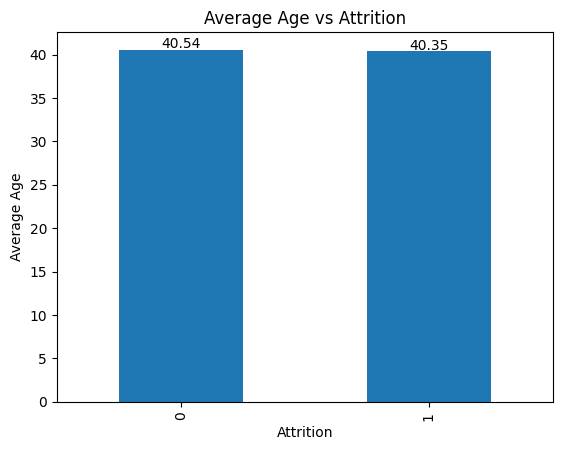

In [36]:
import matplotlib.pyplot as plt

ax = df.groupby('Attrition')['Age'].mean().plot(kind='bar')
plt.title("Average Age vs Attrition")

plt.ylabel("Average Age")

# Add data labels
for i, v in enumerate(df.groupby('Attrition')['Age'].mean()):
    ax.text(i, v + 0.2, round(v,2), ha='center')

plt.show()

##**7.2 Overtime vs Attrition**

Attrition,0,1
OverTime,,
No,5500,1449
Yes,2253,798


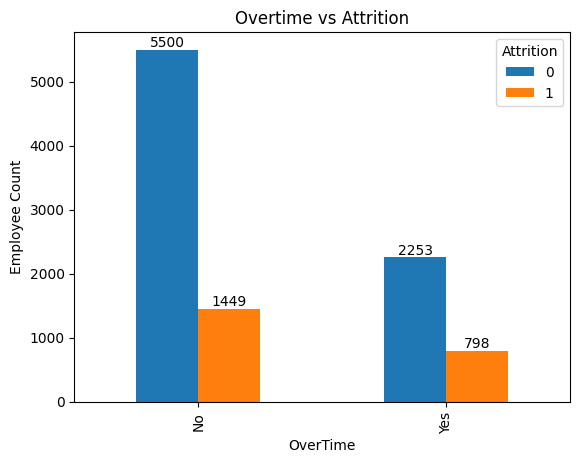

In [37]:
ct = pd.crosstab(df['OverTime'], df['Attrition'])

display(ct)   # ensures table shows in notebook

import matplotlib.pyplot as plt

ax = ct.plot(kind='bar')

plt.title("Overtime vs Attrition")
plt.ylabel("Employee Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

##**7.3 Job Satisfaction vs Attrition**

Attrition,0,1
JobSatisfaction,,
1,1528,545
2,1425,541
3,1567,402
4,1556,397
5,1677,362


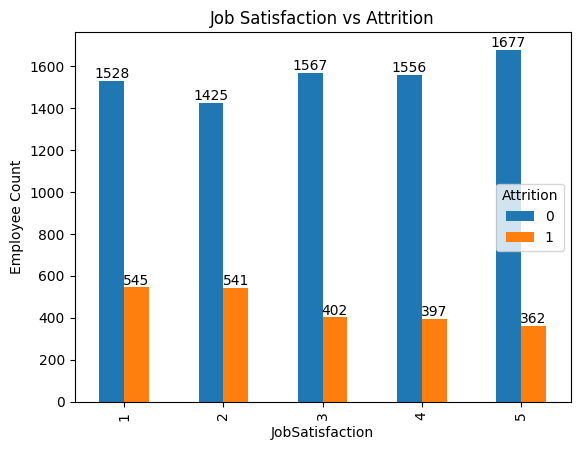

In [38]:
ct = pd.crosstab(df['JobSatisfaction'], df['Attrition'])

display(ct)

ax = ct.plot(kind='bar')

plt.title("Job Satisfaction vs Attrition")
plt.ylabel("Employee Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

##**7.4 Salary vs Attrition**

,MonthlyIncome
Attrition,
0,114409.630853
1,114778.514464


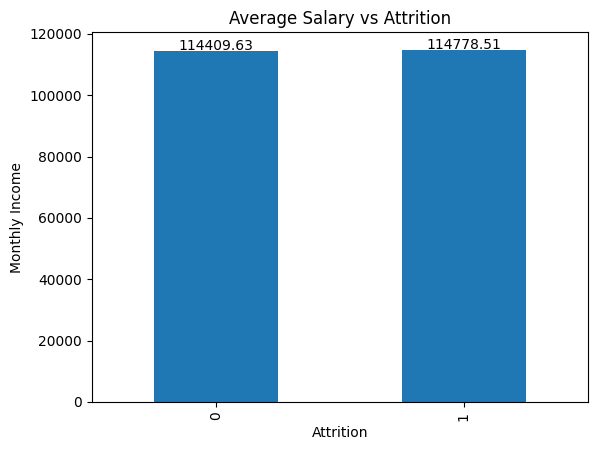

In [39]:
salary = df.groupby('Attrition')['MonthlyIncome'].mean()

display(salary)

ax = salary.plot(kind='bar')

plt.title("Average Salary vs Attrition")
plt.ylabel("Monthly Income")

for i, v in enumerate(salary):
    ax.text(i, v + 200, round(v,2), ha='center')

plt.show()

##**8. Employee Feedback Generation (Synthetic Text Data)**

In [40]:
import random

positive_feedback = [
    "I am happy with my team",
    "Good work life balance",
    "Supportive management",
    "Career growth is good"
]

negative_feedback = [
    "High stress workload",
    "Poor management support",
    "No promotion opportunities",
    "Salary is low"
]

def generate_feedback(attr):
    if attr == 1:
        return random.choice(negative_feedback)
    else:
        return random.choice(positive_feedback)

df['Feedback'] = df['Attrition'].apply(generate_feedback)

##**9. Sentiment Analysis using NLP**

In [41]:
from textblob import TextBlob

# Sentiment analysis
df['Sentiment'] = df['Feedback'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [42]:
df['Sentiment']

,Sentiment
0,-0.4
1,0.0
2,0.5
3,0.0
4,0.8
...,...
9995,0.0
9996,0.7
9997,0.8
9998,0.0


##**10. Text Feature Extraction (TF-IDF)**

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=100)

text_features = vectorizer.fit_transform(df['Feedback'])

text_df = pd.DataFrame(text_features.toarray())

text_df.index = df.index

##**11. Structured Feature Preparation**

* Remove unnecessary columns and encode categorical variables.

In [44]:
X_structured = df.drop([
'Attrition',
'Feedback',
'Employee_ID',
'Attrition_Risk',
'Risk_Score',
'Risk_Level',
'Productivity_Risk_Score',
'Productivity_Risk_Level'
], axis=1, errors='ignore')

In [45]:
X_structured_encoded = pd.get_dummies(X_structured, drop_first=True)

##**12. Feature Fusion**

* Combine structured HR data with text features.

In [46]:
final_X = pd.concat([X_structured_encoded, text_df], axis=1)

In [47]:
y = df['Attrition']

In [48]:
# Convert column names to string
final_X.columns = final_X.columns.astype(str)

In [49]:
# Replace infinity
import numpy as np

final_X.replace([np.inf, -np.inf], np.nan, inplace=True)

final_X = final_X.fillna(0)

##**13. Train-Test Split**

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    final_X, y, test_size=0.2, random_state=42
)

##**14. Machine Learning Model Training**

* Logistic Regression Model.

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

##**15. Feature Importance Analysis**

* Identify drivers of attrition and retention.

In [52]:
importance = pd.Series(model.coef_[0], index=final_X.columns)

top_attrition = importance.sort_values(ascending=False).head(10)
top_retention = importance.sort_values(ascending=True).head(10)

print("\nTop Features Driving Attrition Risk:")
print(top_attrition)

print("\nTop Features Reducing Attrition (Retention Drivers):")
print(top_retention)


Top Features Driving Attrition Risk:
9                                   0.423907
16                                  0.423907
18                                  0.377407
14                                  0.377407
13                                  0.349047
15                                  0.349047
12                                  0.349047
JobLevel                            0.339250
BusinessTravel_Travel Frequently    0.329685
6                                   0.312544
dtype: float64

Top Features Reducing Attrition (Retention Drivers):
Sentiment                 -1.737565
3                         -0.463244
19                        -0.459949
EnvironmentSatisfaction   -0.396271
4                         -0.323177
2                         -0.323177
8                         -0.306398
1                         -0.306398
22                        -0.306398
5                         -0.259195
dtype: float64


##**16. Model Evaluation**

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9035
[[1536   35]
 [ 158  271]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1571
           1       0.89      0.63      0.74       429

    accuracy                           0.90      2000
   macro avg       0.90      0.80      0.84      2000
weighted avg       0.90      0.90      0.90      2000



##**17. Attrition Risk Prediction**

In [54]:
probabilities = model.predict_proba(final_X)[:,1]

In [55]:
df['Attrition_Risk'] = probabilities
df['Risk_Score'] = df['Attrition_Risk'] * 100

In [56]:
df['Risk_Score']

,Risk_Score
0,70.941389
1,56.648611
2,8.225868
3,97.722433
4,0.871517
...,...
9995,60.544460
9996,38.727941
9997,8.424191
9998,26.258928


##**18. Top Employees at Risk**

In [57]:
top_risk = df.sort_values(by='Attrition_Risk', ascending=False).head(10).reset_index(drop=True)
top_risk['Attrition_Risk_%'] = (top_risk['Attrition_Risk'] * 100).round(2)

print("\nTop 10 Employees At Risk:")
top_risk[['Employee_ID','Age','Department','MonthlyIncome','Attrition_Risk_%']].style.background_gradient(cmap='Reds')


Top 10 Employees At Risk:


,Employee_ID,Age,Department,MonthlyIncome,Attrition_Risk_%
0,1885,58,Network Administration,177186,98.790000
1,4474,63,Cyber Security,65595,98.230000
2,7207,61,IT Services,164192,98.120000
3,6438,61,IT Services,153368,97.990000
4,4,60,Data Science,100795,97.720000
5,7809,56,IT Services,34163,97.620000
6,8575,37,Network Administration,104662,97.540000
7,9862,58,Network Administration,190810,97.270000
8,1945,37,Data Science,118912,97.210000
9,2666,42,Data Science,112731,97.110000


##**19. Risk Categorization**

In [59]:
def risk_category(score):

    if score >= 70:
        return "High Risk"

    elif score >= 30:
        return "Medium Risk"

    else:
        return "Low Risk"

df['Risk_Level'] = df['Risk_Score'].apply(risk_category)

In [ ]:
#Assuming weights for the features
#distance from home-50
#overtime-40                   (yes/no)
#job Satisfaction-30 (1-4)
#work life balance 30  (1-4)
#Environment satisfaction 30 (1-4)
#maximum-170

##**20. Productivity Risk Score Calculation**

In [60]:
def productivity_score(row):

    score = 0

    # Job involvement impact
    score += (5 - row['JobInvolvement']) * 20

    # Job satisfaction impact
    score += (5 - row['JobSatisfaction']) * 15

    # Attrition Risk impact
    score += row['Risk_Score'] * 0.3

    return score

df['Productivity_Risk_Score'] = df.apply(productivity_score, axis=1)
# Normalize
df['Productivity_Risk_Score'] = df['Productivity_Risk_Score'] / 170 * 100

##**21. Productivity Risk Level Classification**

In [61]:
def prod_category(score):

    if score >= 70:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

df['Productivity_Risk_Level'] = df['Productivity_Risk_Score'].apply(prod_category)

##**22. Fairness Analysis (Bias Detection)**

**22.1 Gender Bias**

In [69]:
df['Attrition_Risk_%'] = df['Attrition_Risk'] * 100

print("\nFairness Check Across Gender:")
print(df.groupby('Gender')['Attrition_Risk_%'].mean())


Fairness Check Across Gender:
Gender
Female    22.587413
Male      22.354529
Name: Attrition_Risk_%, dtype: float64


##**22.2 Marital Status Bias**

In [70]:
print("\nFairness Check Across Marital Status:")
print(df.groupby('MaritalStatus')['Attrition_Risk_%'].mean())


Fairness Check Across Marital Status:
MaritalStatus
Divorced    21.698101
Married     22.554660
Single      23.182549
Name: Attrition_Risk_%, dtype: float64


##**22.3 Age Group Bias**

In [71]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,30,40,50,60], labels=['18-30','30-40','40-50','50-60'])

print("\nFairness Check Across Age Groups:")
print(df.groupby('AgeGroup', observed=False)['Attrition_Risk_%'].mean())


Fairness Check Across Age Groups:
AgeGroup
18-30    16.098088
30-40    19.847134
40-50    24.206483
50-60    29.271137
Name: Attrition_Risk_%, dtype: float64


##**23. Bias Gap Detection**

In [73]:
print("\nBias Detection Summary")

gender_bias = df.groupby('Gender')['Attrition_Risk_%'].mean()

bias_gap = gender_bias.max() - gender_bias.min()

print("Bias Gap (Gender):", round(bias_gap,2))

if bias_gap > 10:

    print("\n⚠ Potential bias detected between demographic groups.")

    print("\nRecommended Mitigation Strategies:")

    print("1. Rebalance dataset using oversampling techniques like SMOTE.")
    print("2. Remove sensitive attributes such as Gender or MaritalStatus from training.")
    print("3. Apply fairness-aware machine learning algorithms.")
    print("4. Monitor model predictions periodically for demographic bias.")

else:

    print("\n✅ No significant demographic bias detected.")


Bias Detection Summary
Bias Gap (Gender): 0.23

✅ No significant demographic bias detected.


##**24. Model Saving**

In [64]:
import joblib

joblib.dump(model, "/content/drive/My Drive/attrition_model.pkl")
joblib.dump(vectorizer, "/content/drive/My Drive/tfidf_vectorizer.pkl")
joblib.dump(final_X.columns.tolist(), "/content/drive/My Drive/model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!


##**25. Export Final Dataset**

In [65]:
df.to_csv("/content/drive/My Drive/Final_Employee_Risk_Data.csv", index=False)

##**26. Download Model Files**

In [ ]:
from google.colab import files

files.download("/content/drive/My Drive/Final_Employee_Risk_Data.csv")
files.download("/content/drive/My Drive/attrition_model.pkl")
files.download("/content/drive/My Drive/tfidf_vectorizer.pkl")
files.download("/content/drive/My Drive/model_columns.pkl")